# 02 — RFM Analysis

**Goal:** summarize each customer's purchase history in three numbers — the classic retail marketing method:

| Metric | Question | Calculation |
|---|---|---|
| **R**ecency | How long since their last purchase? | Days since last purchase |
| **F**requency | How often do they buy? | Number of distinct invoices |
| **M**onetary | How much do they spend? | Total spent (£) |

This turns hundreds of thousands of transactions into one row per customer (roughly 5,800), which will be the input for clustering.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("../data")

df = pd.read_csv(DATA_DIR / "online_retail_clean.csv",
                 dtype={"Invoice": str, "StockCode": str},
                 parse_dates=["InvoiceDate"])
print(df.shape)

(770398, 9)


## 1. Reference date

Recency is measured relative to "today". Since the data ends in December 2011, we set the reference date to **the day after the last transaction**: a customer who bought on the last day gets a recency of 1.

In [13]:
reference_date = df["InvoiceDate"].max().normalize() + pd.Timedelta(days=1)
print("Reference date:", reference_date.date())

Reference date: 2011-12-10


## 2. Computing RFM per customer

In [14]:
rfm = df.groupby("Customer ID").agg(
    Recency=("InvoiceDate", lambda d: (reference_date - d.max().normalize()).days),
    Frequency=("Invoice", "nunique"),
    Monetary=("LineTotal", "sum"),
)

print(f"{len(rfm):,} customers")
rfm.head()

5,839 customers


,Recency,Frequency,Monetary
Customer ID,,,
12346,530,2,169.36
12347,3,8,4921.53
12348,76,5,1658.40
12349,19,3,3678.69
12350,311,1,294.40


In [15]:
rfm.describe().round(1)

,Recency,Frequency,Monetary
count,5839.0,5839.0,5839.0
mean,200.9,6.2,2820.2
std,208.6,12.6,13876.0
min,1.0,1.0,2.9
25%,26.0,1.0,336.2
50%,96.0,3.0,851.0
75%,380.0,7.0,2206.5
max,739.0,369.0,579128.6


## 3. Distributions

Expected finding: the distributions are highly **skewed**. Most customers buy little, while a handful buy a lot.

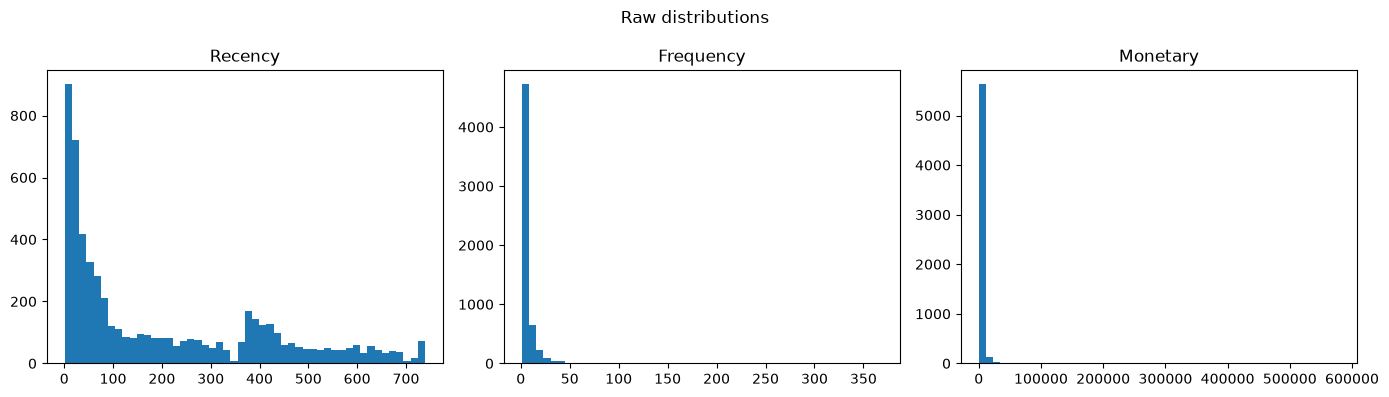

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, rfm.columns):
    ax.hist(rfm[col], bins=50)
    ax.set_title(col)
plt.suptitle("Raw distributions")
plt.tight_layout()
plt.show()

## 4. The biggest customers

Who are the extreme customers? Many customers in this dataset are **wholesalers**, and their totals dwarf everyone else's.

In [17]:
rfm.sort_values("Monetary", ascending=False).head(10)

,Recency,Frequency,Monetary
Customer ID,,,
18102,1,145,579128.64
14646,2,143,523361.34
14156,10,143,298378.79
14911,2,369,259866.38
17450,9,49,233675.91
13694,4,141,191233.07
17511,3,59,169626.87
12415,25,23,143275.72
16684,5,53,141955.55


In [18]:
top1_share = (rfm["Monetary"].nlargest(int(len(rfm) * 0.01)).sum()
              / rfm["Monetary"].sum())
print(f"The top 1% of customers account for {top1_share:.1%} of revenue")

The top 1% of customers account for 31.0% of revenue


K-means works with distances: without a transformation, these few giants would dominate the clustering. Rather than removing them (they are real customers, and the most valuable ones), we apply a **log transformation** that compresses large values.

## 5. Log transformation

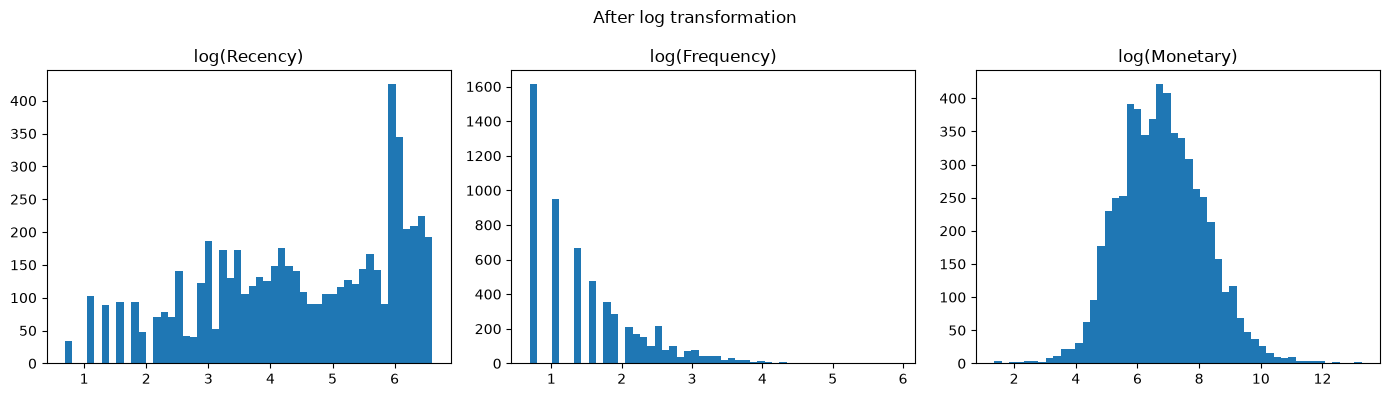

In [19]:
rfm_log = np.log1p(rfm)   # log(1 + x): also handles values close to 0

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, rfm_log.columns):
    ax.hist(rfm_log[col], bins=50)
    ax.set_title(f"log({col})")
plt.suptitle("After log transformation")
plt.tight_layout()
plt.show()

What the transformation achieves — and what it doesn't:

- **Monetary** now has a nearly symmetric, bell-shaped distribution: the giants no longer dominate.
- **Recency** is better spread out, but shows a large peak around 6 (about 400 days): many customers made their last purchase roughly a year before the end of the data — possibly holiday shoppers from late 2010 who never came back.
- **Frequency** remains heavily skewed: the tall bar on the left is the large group of **one-time buyers**. A log can compress large values, but it can't spread out thousands of customers who share the exact same value. These customers will likely form their own segment — which makes business sense.

**Standardization** (mean 0, standard deviation 1) will be done in notebook 03, right before clustering.

## 6. Classic RFM scores (baseline for comparison)

Before machine learning, retailers segmented customers with **scores from 1 to 5**: customers are ranked into 5 equal groups (quintiles) for each metric. We compute these scores so that notebook 03 can compare the traditional approach with K-means.

*Note:* for recency, **lower is better**, so the score is reversed.

In [20]:
def quintile_score(series, reverse=False):
    labels = [5, 4, 3, 2, 1] if reverse else [1, 2, 3, 4, 5]
    # rank(method="first") avoids errors when many customers share the same value
    return pd.qcut(series.rank(method="first"), 5, labels=labels).astype(int)

rfm["R_score"] = quintile_score(rfm["Recency"], reverse=True)
rfm["F_score"] = quintile_score(rfm["Frequency"])
rfm["M_score"] = quintile_score(rfm["Monetary"])
rfm["RFM_score"] = rfm[["R_score", "F_score", "M_score"]].sum(axis=1)

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score
Customer ID,,,,,,,
12346,530,2,169.36,1,2,1,4
12347,3,8,4921.53,5,4,5,14
12348,76,5,1658.40,3,4,4,11
12349,19,3,3678.69,5,3,5,13
12350,311,1,294.40,2,1,2,5


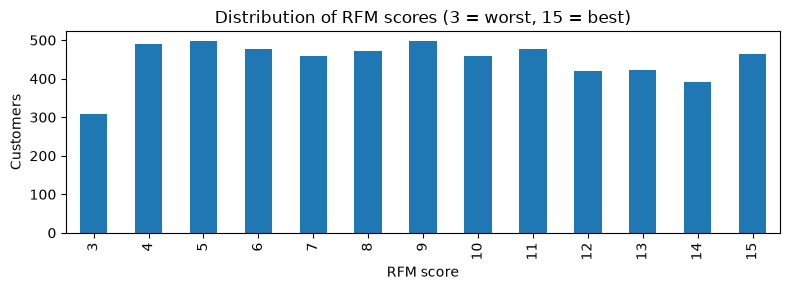

In [21]:
rfm["RFM_score"].value_counts().sort_index().plot(kind="bar", figsize=(8, 3))
plt.title("Distribution of RFM scores (3 = worst, 15 = best)")
plt.xlabel("RFM score")
plt.ylabel("Customers")
plt.tight_layout()
plt.show()

## 7. Saving

In [22]:
rfm.to_csv(DATA_DIR / "rfm.csv")
print("Saved:", DATA_DIR / "rfm.csv")

Saved: ..\data\rfm.csv


## Next step

`03_clustering.ipynb`: standardization, choosing the number of segments (elbow method + silhouette score), K-means, then interpreting the segments in business terms.